In [1]:
import os
import re
from functools import lru_cache
from pathlib import Path

import numpy as np
import pandas as pd

RANDOM_STATE = 42
METRIC = "euclidean"

PATH = Path("year_MNSENA_results_cut")      # parquet files + qtransform PDFs
CACHE_DIR = Path("embeddings_cache")        # embeddings are stored here
CACHE_DIR.mkdir(exist_ok=True)

# year -> t-SNE perplexity (same values as mn-sena-splited.ipynb)
YEARS = {2022: 250, 2023: 220, 2024: 220, 2025: 220}

# label shown in the UI -> key stored inside embeddings_<year>.npz
PROJECTIONS = {"t-SNE": "tsne", "UMAP": "umap"}

In [2]:
emb_2022 = np.load("embeddings_cache/embeddings_2022.npz")
emb_2023 = np.load("embeddings_cache/embeddings_2023.npz")
emb_2024 = np.load("embeddings_cache/embeddings_2024.npz")
emb_2025 = np.load("embeddings_cache/embeddings_2025.npz")

print(emb_2022["tsne"].T[0])

[  6.0269184 -20.014738  -30.233967  ... -38.511185  -30.755335
 -25.693077 ]


In [3]:
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN, HDBSCAN

2022

In [4]:
X1 = emb_2022["tsne"].T[0]
X2 = emb_2022["tsne"].T[1]

kde = gaussian_kde(np.vstack([X1,X2]))

X, Y = np.meshgrid(np.linspace(X1.min(), X1.max(),500),np.linspace(X2.min(), X2.max(),500))
Z = kde(np.vstack([X.ravel(),Y.ravel()])).reshape(X.shape)

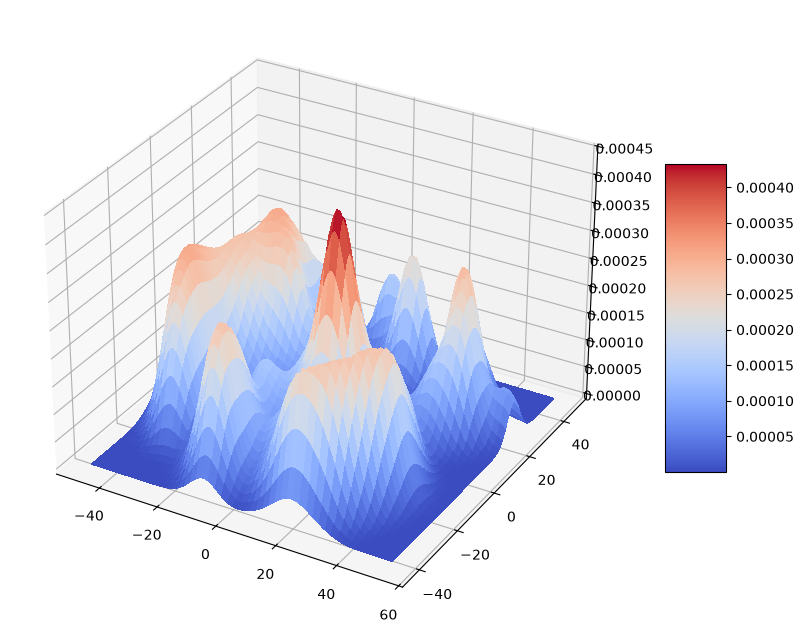

In [5]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")

surf =ax.plot_surface(X, Y, Z, cmap="coolwarm",linewidth=0, antialiased=False)
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

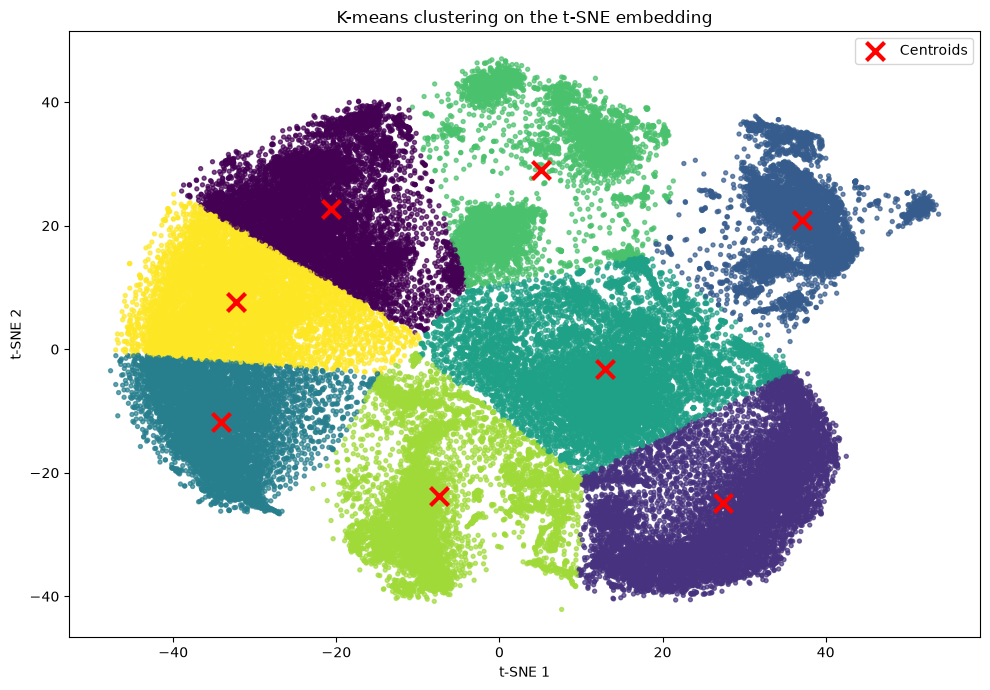

In [6]:
A = np.asarray(emb_2022["tsne"].tolist())
kmeans = KMeans(init="k-means++", n_clusters=8, n_init="auto", random_state=42).fit(A)
plt.figure(figsize=(10, 7))

plt.scatter(A[:, 0],A[:, 1],c=kmeans.labels_,cmap="viridis",s=8,alpha=0.7)
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0],centroids[:, 1],marker="x",s=169,linewidths=3,color="red",zorder=10,label="Centroids")

plt.title("K-means clustering on the t-SNE embedding")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend()
plt.tight_layout()
plt.show()

Estimated number of clusters: 9
Estimated number of noise points: 4847


/tmp/ipykernel_7155/3381774338.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


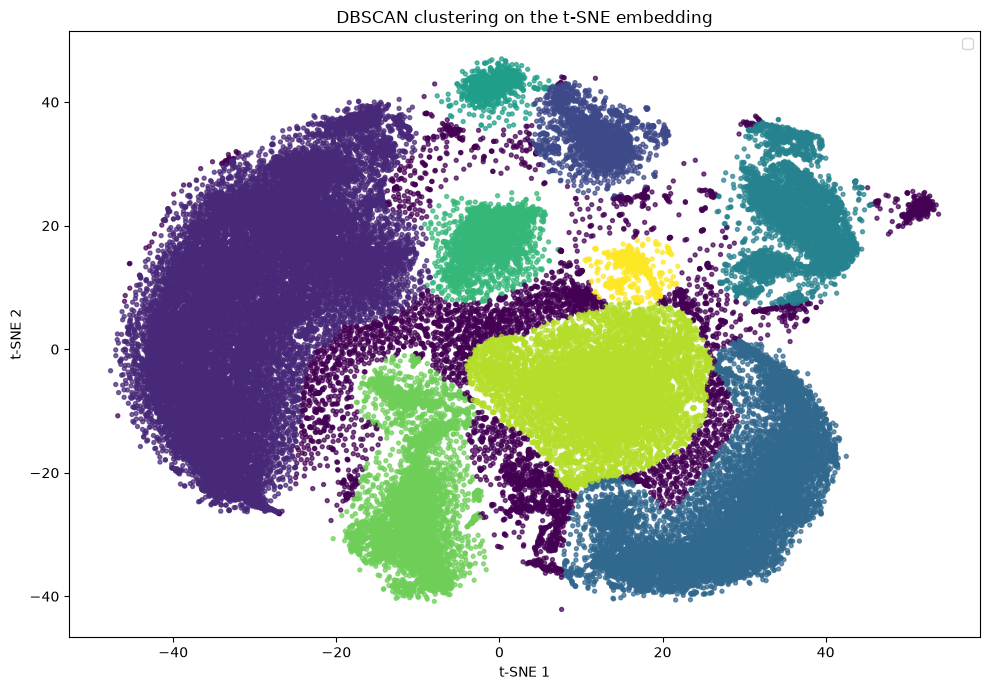

In [7]:
dbscan = DBSCAN(eps=4, min_samples=500, metric=METRIC).fit(A)

plt.figure(figsize=(10, 7))
plt.scatter(A[:, 0],A[:, 1],c=dbscan.labels_,cmap="viridis",s=8,alpha=0.7)

labels = dbscan.labels_
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

plt.title("DBSCAN clustering on the t-SNE embedding")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend()
plt.tight_layout()
plt.show()

/home/rauls/Desktop/VirgoBRET/.venv/lib/python3.14/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


Estimated number of clusters: 10
Estimated number of noise points: 14888


/tmp/ipykernel_7155/905447596.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


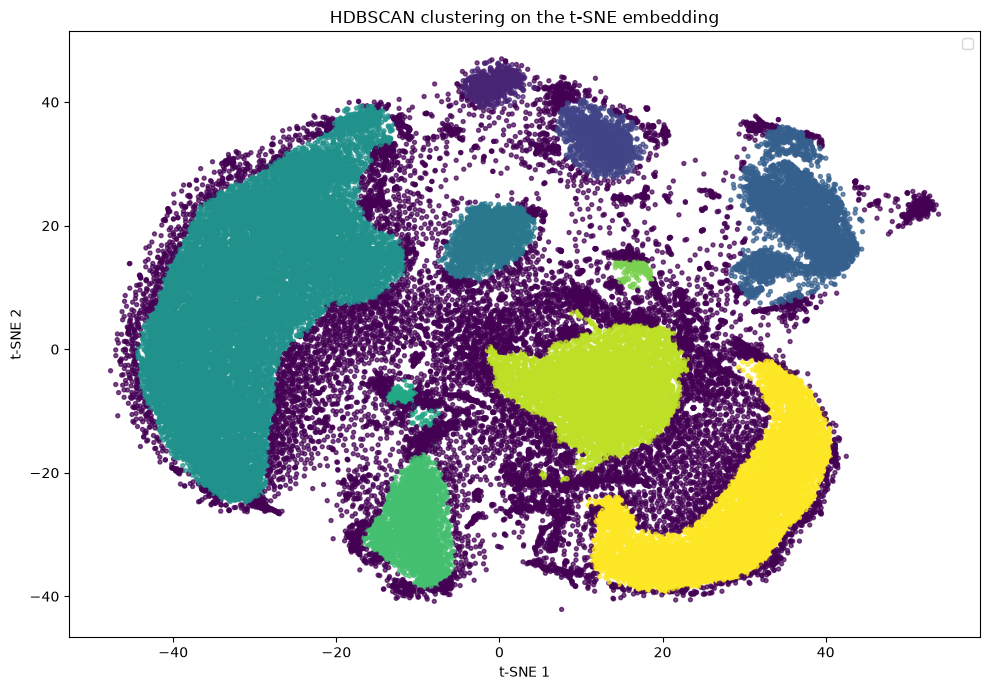

In [8]:
hdbscan = HDBSCAN(min_samples=500, metric=METRIC).fit(A)

plt.figure(figsize=(10, 7))
plt.scatter(A[:, 0],A[:, 1],c=hdbscan.labels_,cmap="viridis",s=8,alpha=0.7)

labels = hdbscan.labels_
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

plt.title("HDBSCAN clustering on the t-SNE embedding")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend()
plt.tight_layout()
plt.show()

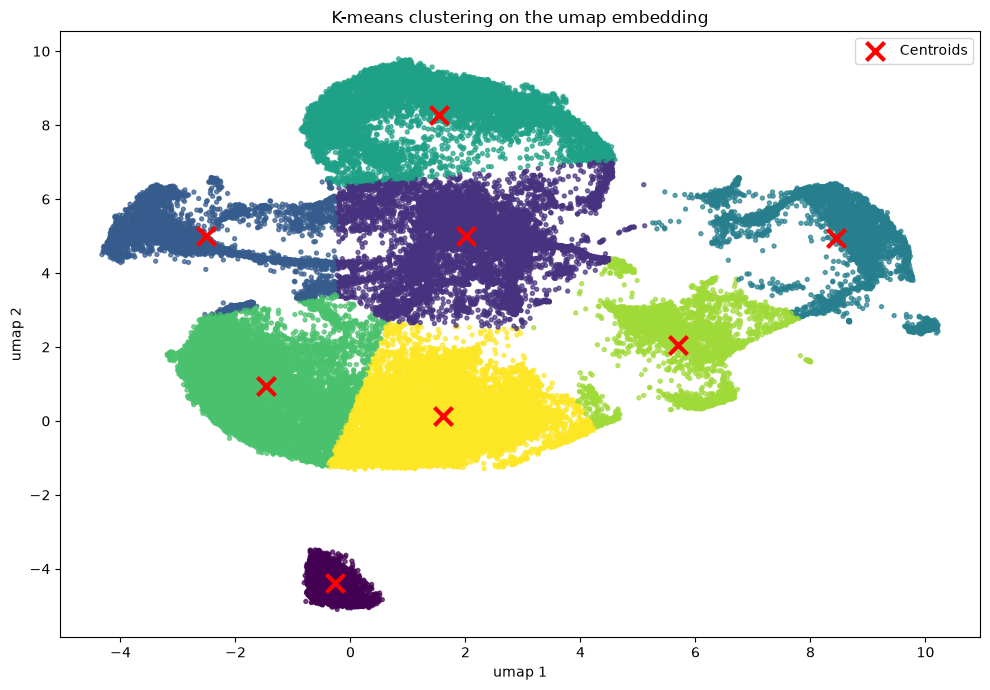

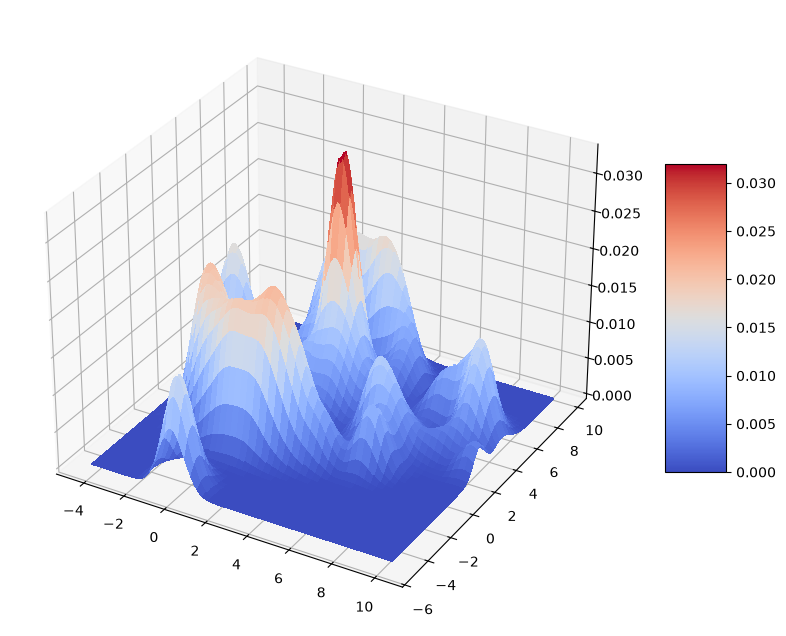

In [9]:
X1 = emb_2022["umap"].T[0]
X2 = emb_2022["umap"].T[1]

A = np.asarray(emb_2022["umap"].tolist())
kmeans = KMeans(init="k-means++", n_clusters=8, n_init="auto", random_state=42).fit(A)
plt.figure(figsize=(10, 7))

plt.scatter(A[:, 0],A[:, 1],c=kmeans.labels_,cmap="viridis",s=8,alpha=0.7)
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0],centroids[:, 1],marker="x",s=169,linewidths=3,color="red",zorder=10,label="Centroids")

plt.title("K-means clustering on the umap embedding")
plt.xlabel("umap 1")
plt.ylabel("umap 2")
plt.legend()
plt.tight_layout()
plt.show()

kde = gaussian_kde(np.vstack([X1,X2]))

X, Y = np.meshgrid(np.linspace(X1.min(), X1.max(),500),np.linspace(X2.min(), X2.max(),500))
Z = kde(np.vstack([X.ravel(),Y.ravel()])).reshape(X.shape)

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")

surf =ax.plot_surface(X, Y, Z, cmap="coolwarm",linewidth=0, antialiased=False)
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

Estimated number of clusters: 2
Estimated number of noise points: 0


/tmp/ipykernel_7155/394792188.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


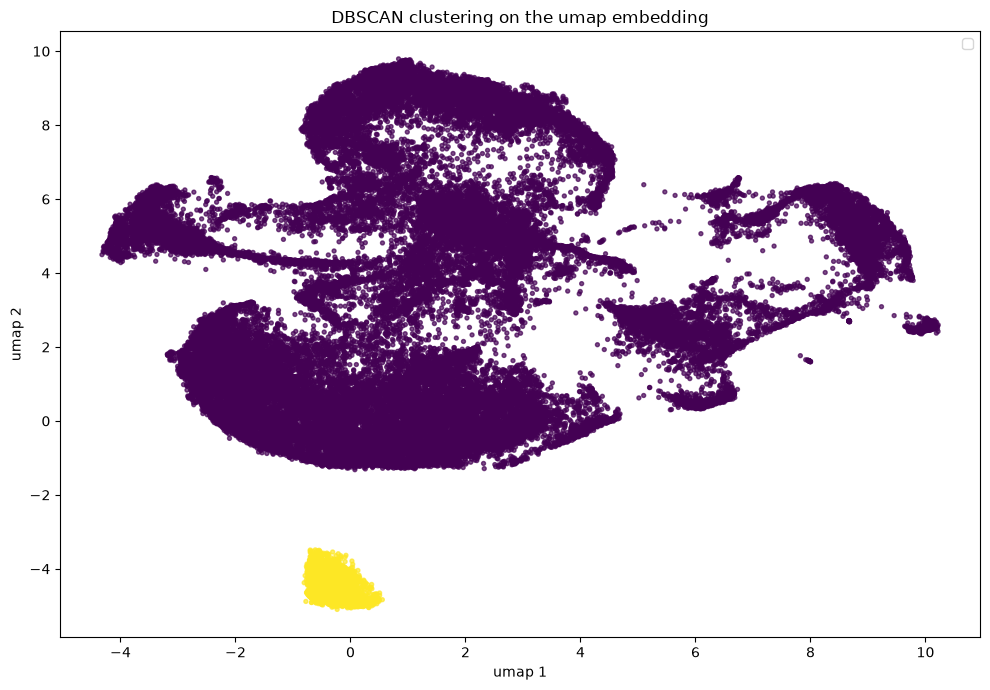

/home/rauls/Desktop/VirgoBRET/.venv/lib/python3.14/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


Estimated number of clusters: 2
Estimated number of noise points: 0


/tmp/ipykernel_7155/394792188.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


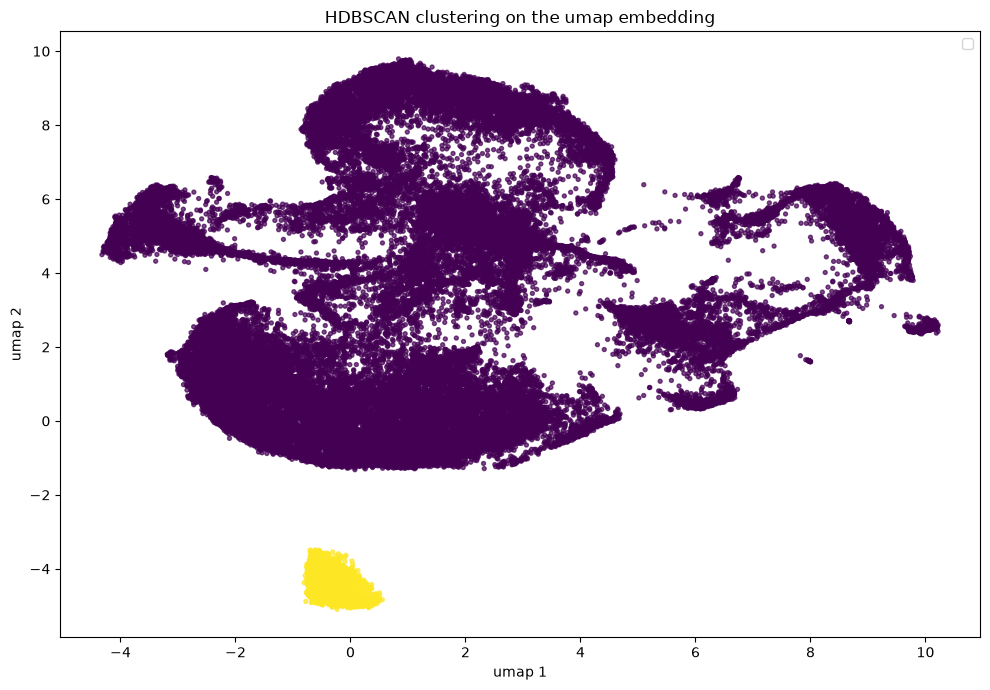

In [10]:
dbscan = DBSCAN(eps=2, min_samples=500, metric=METRIC).fit(A)

plt.figure(figsize=(10, 7))
plt.scatter(A[:, 0],A[:, 1],c=dbscan.labels_,cmap="viridis",s=8,alpha=0.7)

labels = dbscan.labels_
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

plt.title("DBSCAN clustering on the umap embedding")
plt.xlabel("umap 1")
plt.ylabel("umap 2")
plt.legend()
plt.tight_layout()
plt.show()

hdbscan = HDBSCAN(min_samples=500, metric=METRIC).fit(A)

plt.figure(figsize=(10, 7))
plt.scatter(A[:, 0],A[:, 1],c=hdbscan.labels_,cmap="viridis",s=8,alpha=0.7)

labels = hdbscan.labels_
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

plt.title("HDBSCAN clustering on the umap embedding")
plt.xlabel("umap 1")
plt.ylabel("umap 2")
plt.legend()
plt.tight_layout()
plt.show()

2023

In [11]:
X1 = emb_2023["tsne"].T[0]
X2 = emb_2023["tsne"].T[1]

kde = gaussian_kde(np.vstack([X1,X2]))

X, Y = np.meshgrid(np.linspace(X1.min(), X1.max(),500),np.linspace(X2.min(), X2.max(),500))
Z = kde(np.vstack([X.ravel(),Y.ravel()])).reshape(X.shape)

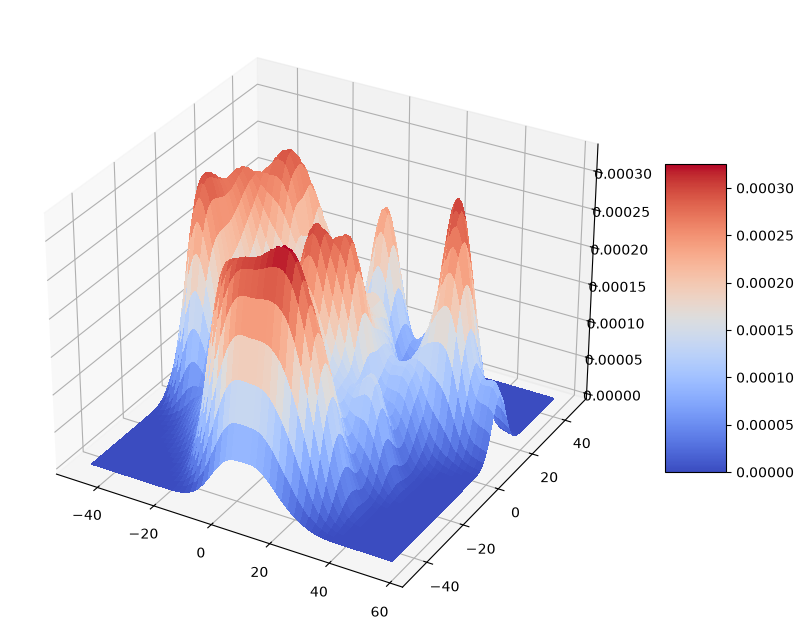

In [12]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")

surf =ax.plot_surface(X, Y, Z, cmap="coolwarm",linewidth=0, antialiased=False)
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

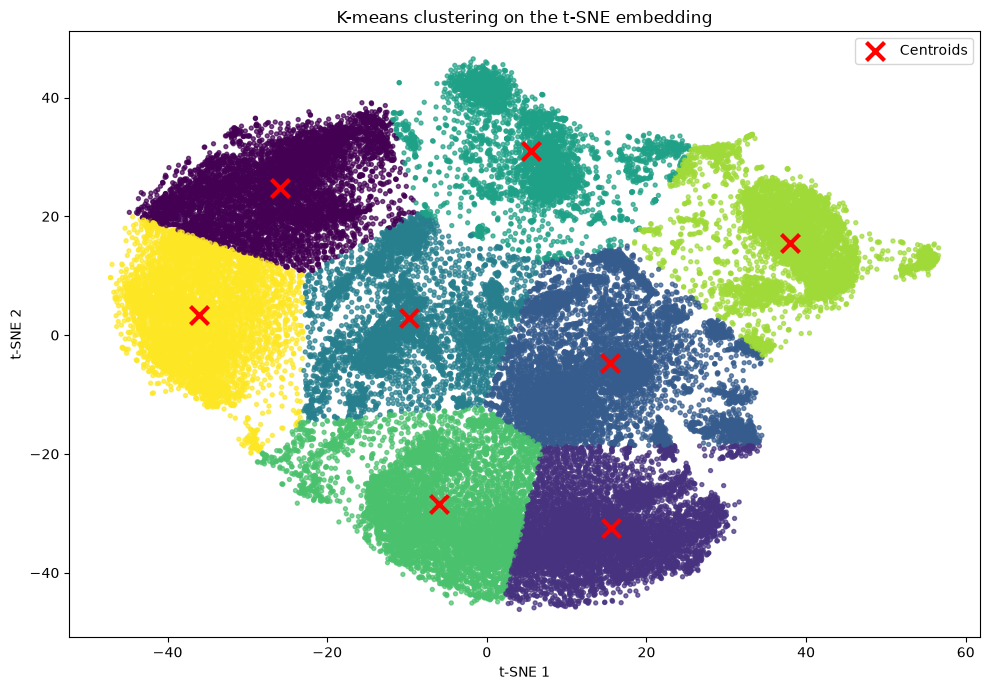

In [13]:
A = np.asarray(emb_2023["tsne"].tolist())
kmeans = KMeans(init="k-means++", n_clusters=8, n_init="auto", random_state=42).fit(A)
plt.figure(figsize=(10, 7))

plt.scatter(A[:, 0],A[:, 1],c=kmeans.labels_,cmap="viridis",s=8,alpha=0.7)
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0],centroids[:, 1],marker="x",s=169,linewidths=3,color="red",zorder=10,label="Centroids")

plt.title("K-means clustering on the t-SNE embedding")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend()
plt.tight_layout()
plt.show()

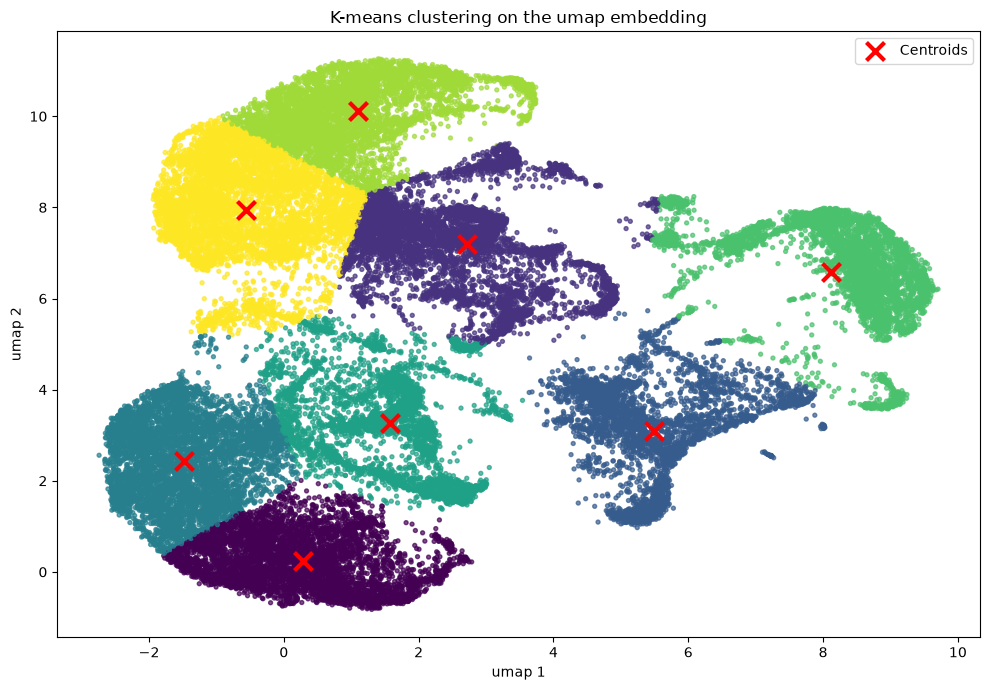

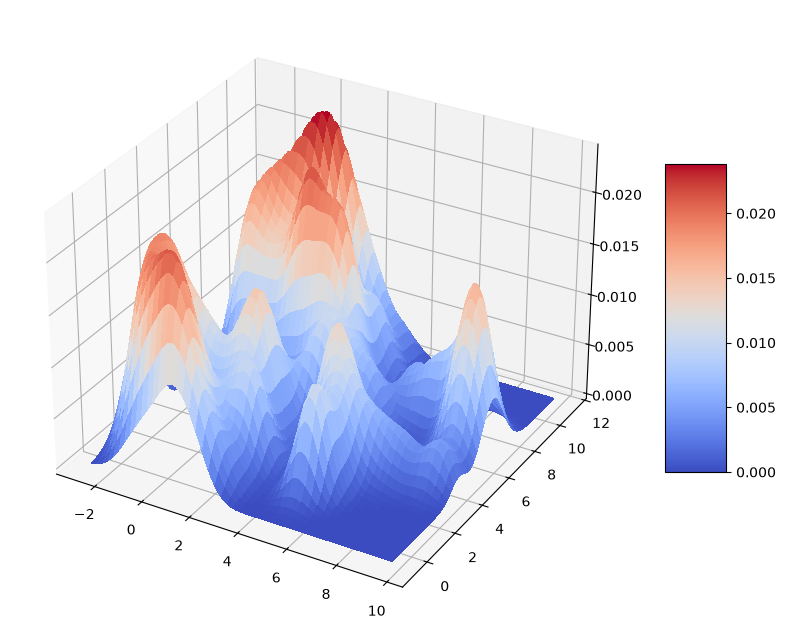

In [14]:
X1 = emb_2023["umap"].T[0]
X2 = emb_2023["umap"].T[1]

A = np.asarray(emb_2023["umap"].tolist())
kmeans = KMeans(init="k-means++", n_clusters=8, n_init="auto", random_state=42).fit(A)
plt.figure(figsize=(10, 7))

plt.scatter(A[:, 0],A[:, 1],c=kmeans.labels_,cmap="viridis",s=8,alpha=0.7)
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0],centroids[:, 1],marker="x",s=169,linewidths=3,color="red",zorder=10,label="Centroids")

plt.title("K-means clustering on the umap embedding")
plt.xlabel("umap 1")
plt.ylabel("umap 2")
plt.legend()
plt.tight_layout()
plt.show()

kde = gaussian_kde(np.vstack([X1,X2]))

X, Y = np.meshgrid(np.linspace(X1.min(), X1.max(),500),np.linspace(X2.min(), X2.max(),500))
Z = kde(np.vstack([X.ravel(),Y.ravel()])).reshape(X.shape)

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")

surf =ax.plot_surface(X, Y, Z, cmap="coolwarm",linewidth=0, antialiased=False)
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

Estimated number of clusters: 1
Estimated number of noise points: 0


/tmp/ipykernel_7155/27533357.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


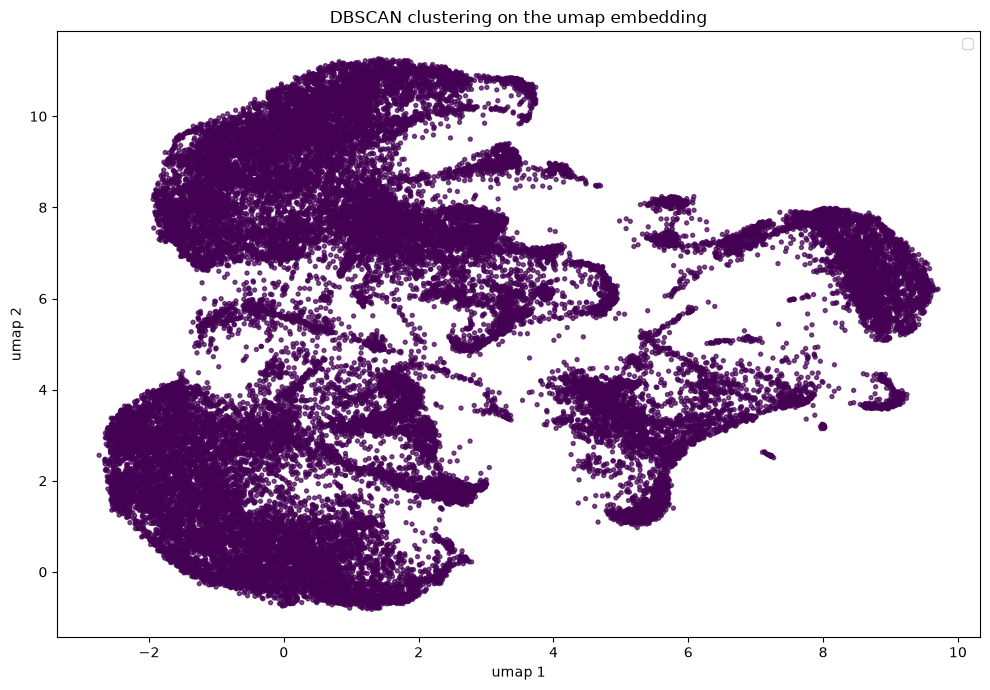

/home/rauls/Desktop/VirgoBRET/.venv/lib/python3.14/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


Estimated number of clusters: 11
Estimated number of noise points: 10276


/tmp/ipykernel_7155/27533357.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


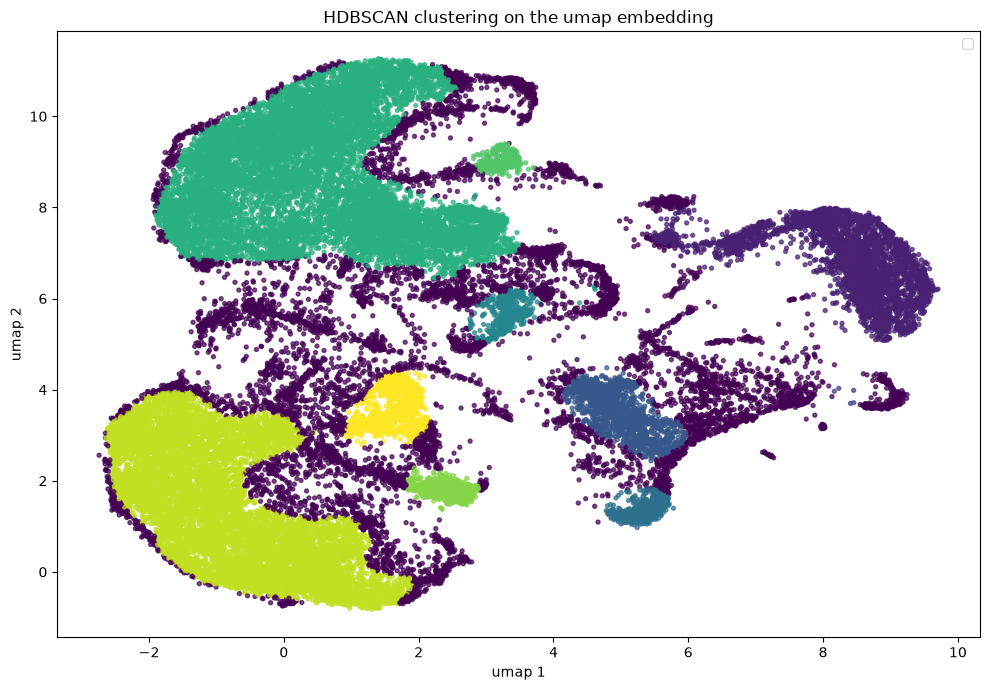

In [15]:
dbscan = DBSCAN(eps=4, min_samples=500, metric=METRIC).fit(A)

plt.figure(figsize=(10, 7))
plt.scatter(A[:, 0],A[:, 1],c=dbscan.labels_,cmap="viridis",s=8,alpha=0.7)

labels = dbscan.labels_
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

plt.title("DBSCAN clustering on the umap embedding")
plt.xlabel("umap 1")
plt.ylabel("umap 2")
plt.legend()
plt.tight_layout()
plt.show()

hdbscan = HDBSCAN(min_samples=500, metric=METRIC).fit(A)

plt.figure(figsize=(10, 7))
plt.scatter(A[:, 0],A[:, 1],c=hdbscan.labels_,cmap="viridis",s=8,alpha=0.7)

labels = hdbscan.labels_
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

plt.title("HDBSCAN clustering on the umap embedding")
plt.xlabel("umap 1")
plt.ylabel("umap 2")
plt.legend()
plt.tight_layout()
plt.show()

2024

In [16]:
X1 = emb_2024["tsne"].T[0]
X2 = emb_2024["tsne"].T[1]

kde = gaussian_kde(np.vstack([X1,X2]))

X, Y = np.meshgrid(np.linspace(X1.min(), X1.max(),500),np.linspace(X2.min(), X2.max(),500))
Z = kde(np.vstack([X.ravel(),Y.ravel()])).reshape(X.shape)

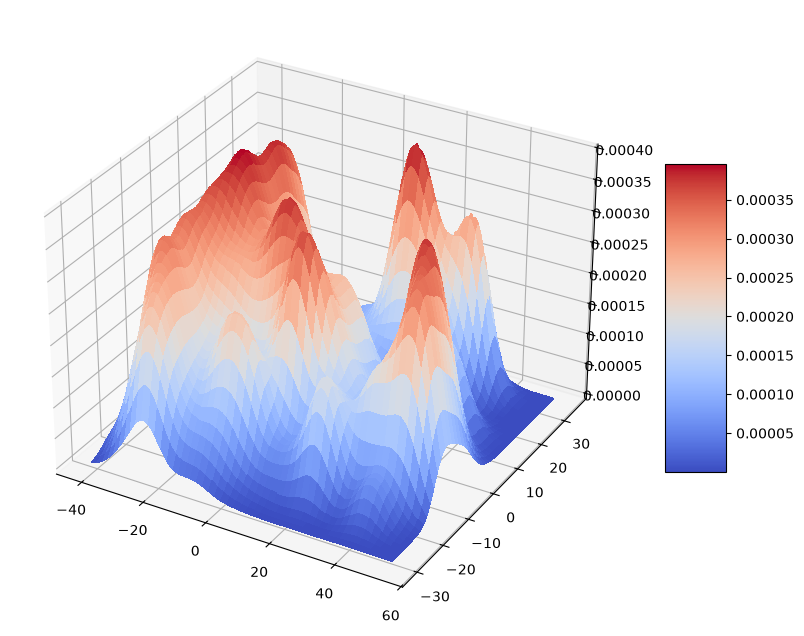

In [17]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")

surf =ax.plot_surface(X, Y, Z, cmap="coolwarm",linewidth=0, antialiased=False)
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

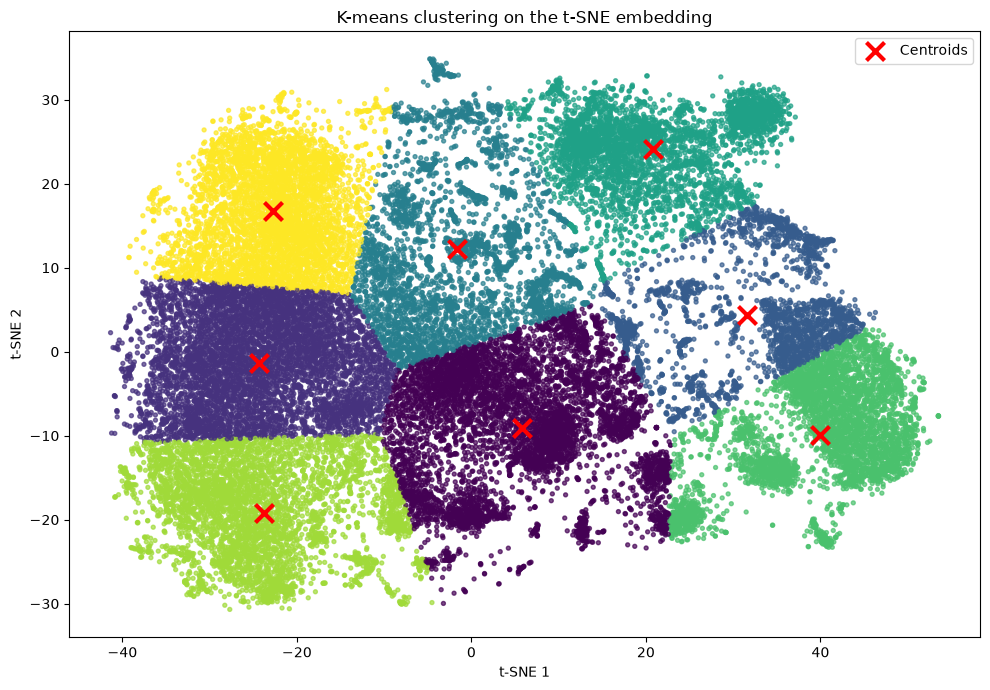

In [18]:
A = np.asarray(emb_2024["tsne"].tolist())
kmeans = KMeans(init="k-means++", n_clusters=8, n_init="auto", random_state=42).fit(A)
plt.figure(figsize=(10, 7))

plt.scatter(A[:, 0],A[:, 1],c=kmeans.labels_,cmap="viridis",s=8,alpha=0.7)
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0],centroids[:, 1],marker="x",s=169,linewidths=3,color="red",zorder=10,label="Centroids")

plt.title("K-means clustering on the t-SNE embedding")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend()
plt.tight_layout()
plt.show()

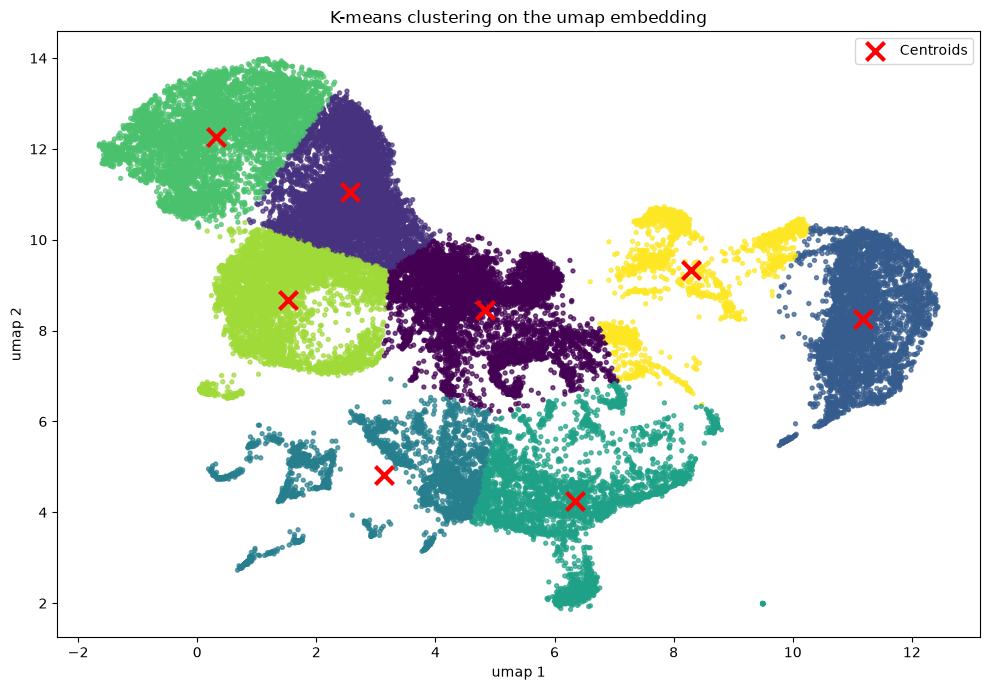

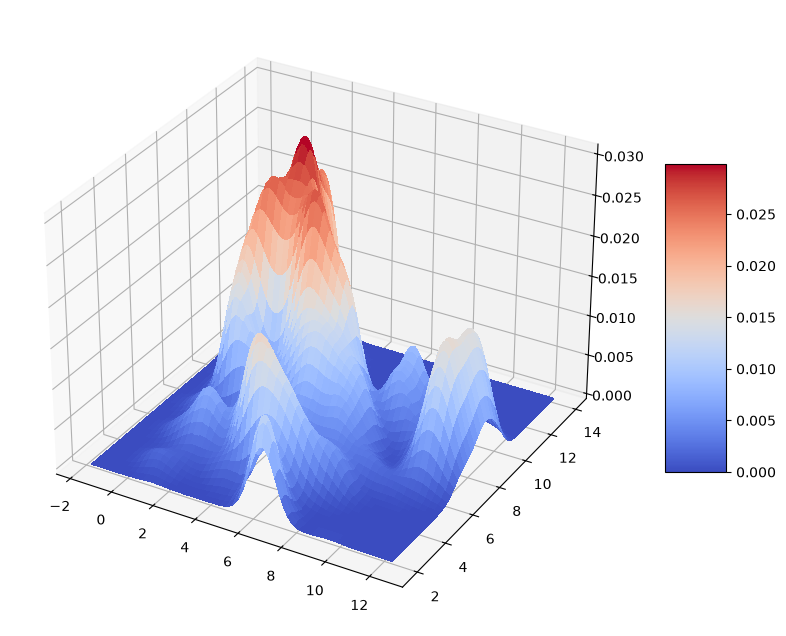

In [19]:
X1 = emb_2024["umap"].T[0]
X2 = emb_2024["umap"].T[1]

A = np.asarray(emb_2024["umap"].tolist())
kmeans = KMeans(init="k-means++", n_clusters=8, n_init="auto", random_state=42).fit(A)
plt.figure(figsize=(10, 7))

plt.scatter(A[:, 0],A[:, 1],c=kmeans.labels_,cmap="viridis",s=8,alpha=0.7)
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0],centroids[:, 1],marker="x",s=169,linewidths=3,color="red",zorder=10,label="Centroids")

plt.title("K-means clustering on the umap embedding")
plt.xlabel("umap 1")
plt.ylabel("umap 2")
plt.legend()
plt.tight_layout()
plt.show()

kde = gaussian_kde(np.vstack([X1,X2]))

X, Y = np.meshgrid(np.linspace(X1.min(), X1.max(),500),np.linspace(X2.min(), X2.max(),500))
Z = kde(np.vstack([X.ravel(),Y.ravel()])).reshape(X.shape)

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")

surf =ax.plot_surface(X, Y, Z, cmap="coolwarm",linewidth=0, antialiased=False)
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

Estimated number of clusters: 1
Estimated number of noise points: 0


/tmp/ipykernel_7155/27533357.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


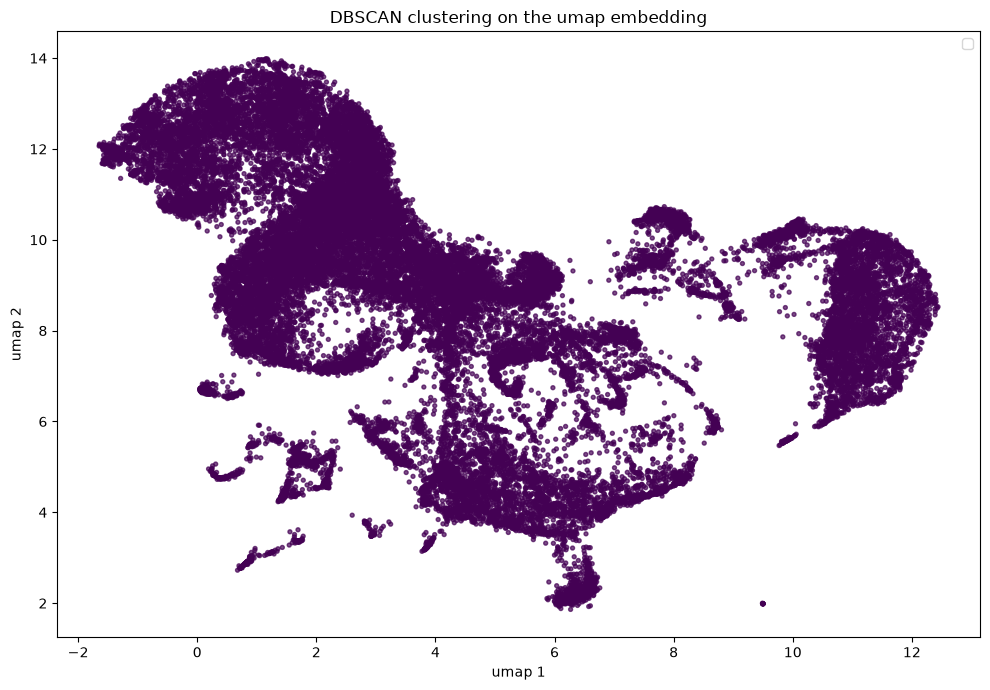

/home/rauls/Desktop/VirgoBRET/.venv/lib/python3.14/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


Estimated number of clusters: 6
Estimated number of noise points: 4943


/tmp/ipykernel_7155/27533357.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


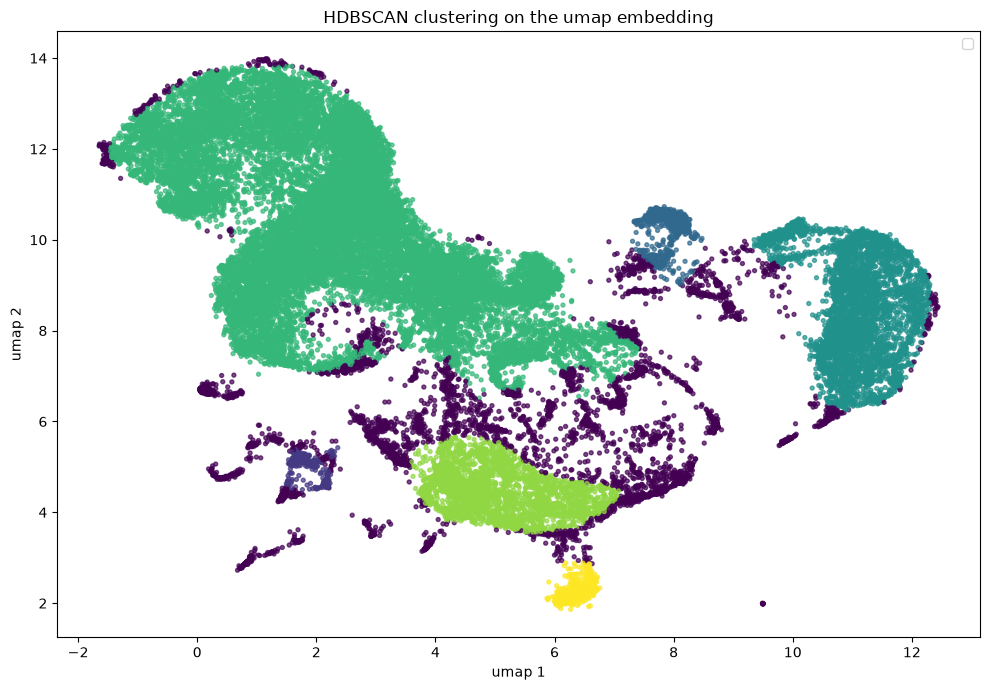

In [20]:
dbscan = DBSCAN(eps=4, min_samples=500, metric=METRIC).fit(A)

plt.figure(figsize=(10, 7))
plt.scatter(A[:, 0],A[:, 1],c=dbscan.labels_,cmap="viridis",s=8,alpha=0.7)

labels = dbscan.labels_
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

plt.title("DBSCAN clustering on the umap embedding")
plt.xlabel("umap 1")
plt.ylabel("umap 2")
plt.legend()
plt.tight_layout()
plt.show()

hdbscan = HDBSCAN(min_samples=500, metric=METRIC).fit(A)

plt.figure(figsize=(10, 7))
plt.scatter(A[:, 0],A[:, 1],c=hdbscan.labels_,cmap="viridis",s=8,alpha=0.7)

labels = hdbscan.labels_
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

plt.title("HDBSCAN clustering on the umap embedding")
plt.xlabel("umap 1")
plt.ylabel("umap 2")
plt.legend()
plt.tight_layout()
plt.show()

2025

In [21]:
X1 = emb_2025["tsne"].T[0]
X2 = emb_2025["tsne"].T[1]

kde = gaussian_kde(np.vstack([X1,X2]))

X, Y = np.meshgrid(np.linspace(X1.min(), X1.max(),500),np.linspace(X2.min(), X2.max(),500))
Z = kde(np.vstack([X.ravel(),Y.ravel()])).reshape(X.shape)

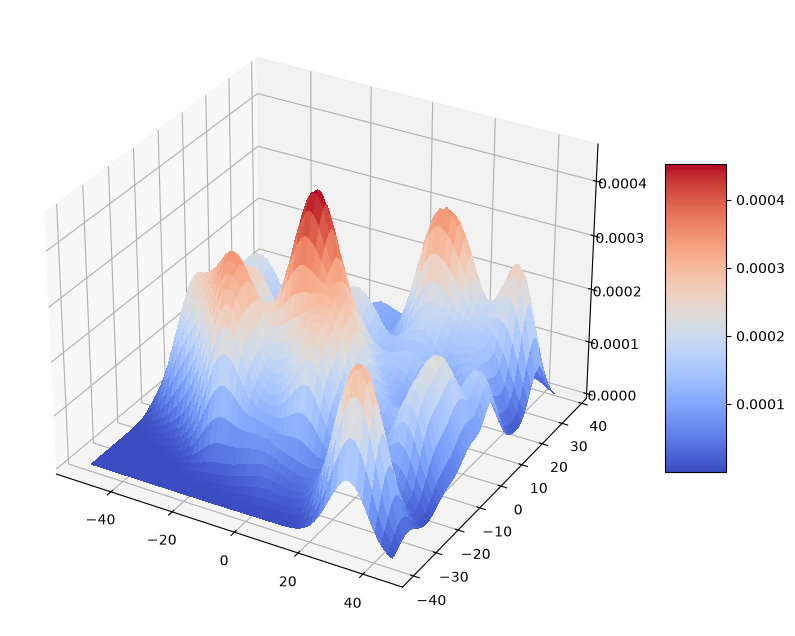

In [22]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")

surf =ax.plot_surface(X, Y, Z, cmap="coolwarm",linewidth=0, antialiased=False)
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

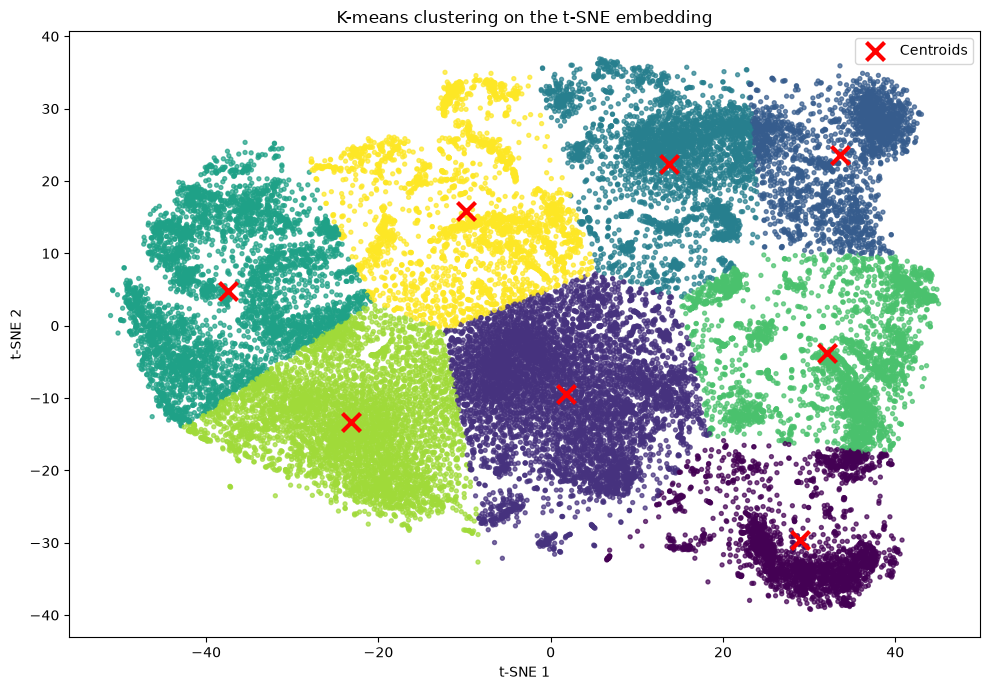

In [23]:
A = np.asarray(emb_2025["tsne"].tolist())
kmeans = KMeans(init="k-means++", n_clusters=8, n_init="auto", random_state=42).fit(A)
plt.figure(figsize=(10, 7))

plt.scatter(A[:, 0],A[:, 1],c=kmeans.labels_,cmap="viridis",s=8,alpha=0.7)
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0],centroids[:, 1],marker="x",s=169,linewidths=3,color="red",zorder=10,label="Centroids")

plt.title("K-means clustering on the t-SNE embedding")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend()
plt.tight_layout()
plt.show()

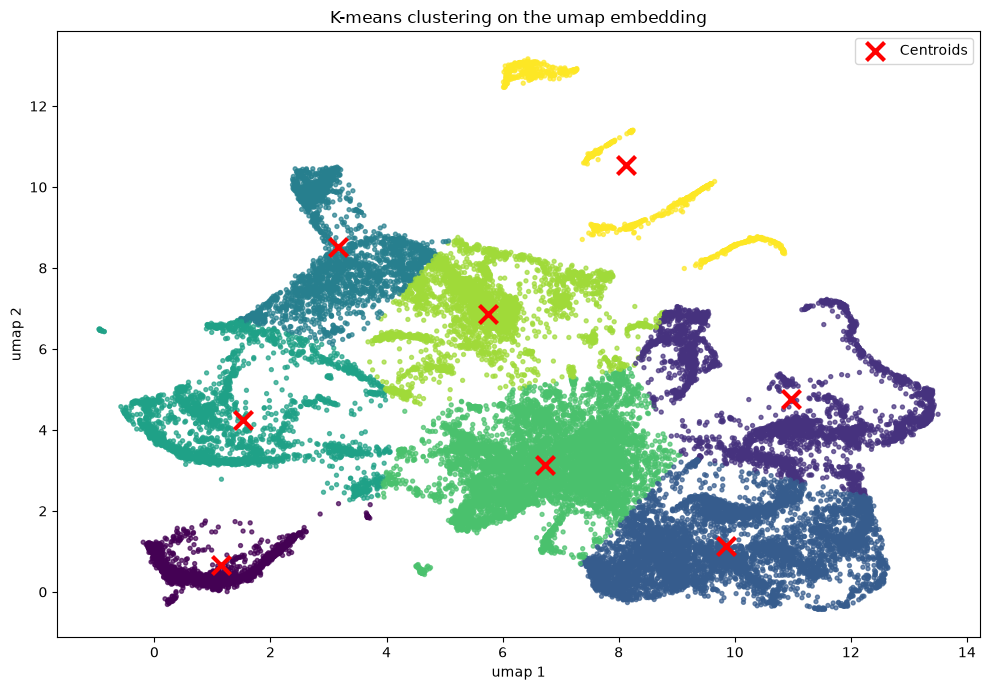

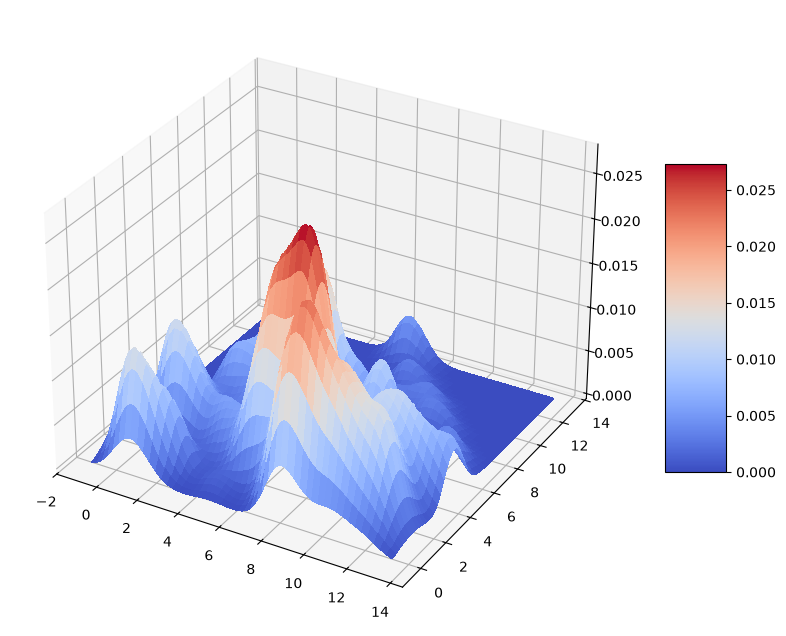

In [24]:
X1 = emb_2025["umap"].T[0]
X2 = emb_2025["umap"].T[1]

A = np.asarray(emb_2025["umap"].tolist())
kmeans = KMeans(init="k-means++", n_clusters=8, n_init="auto", random_state=42).fit(A)
plt.figure(figsize=(10, 7))

plt.scatter(A[:, 0],A[:, 1],c=kmeans.labels_,cmap="viridis",s=8,alpha=0.7)
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0],centroids[:, 1],marker="x",s=169,linewidths=3,color="red",zorder=10,label="Centroids")

plt.title("K-means clustering on the umap embedding")
plt.xlabel("umap 1")
plt.ylabel("umap 2")
plt.legend()
plt.tight_layout()
plt.show()


kde = gaussian_kde(np.vstack([X1,X2]))

X, Y = np.meshgrid(np.linspace(X1.min(), X1.max(),500),np.linspace(X2.min(), X2.max(),500))
Z = kde(np.vstack([X.ravel(),Y.ravel()])).reshape(X.shape)

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")

surf =ax.plot_surface(X, Y, Z, cmap="coolwarm",linewidth=0, antialiased=False)
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

Estimated number of clusters: 1
Estimated number of noise points: 0


/tmp/ipykernel_7155/27533357.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


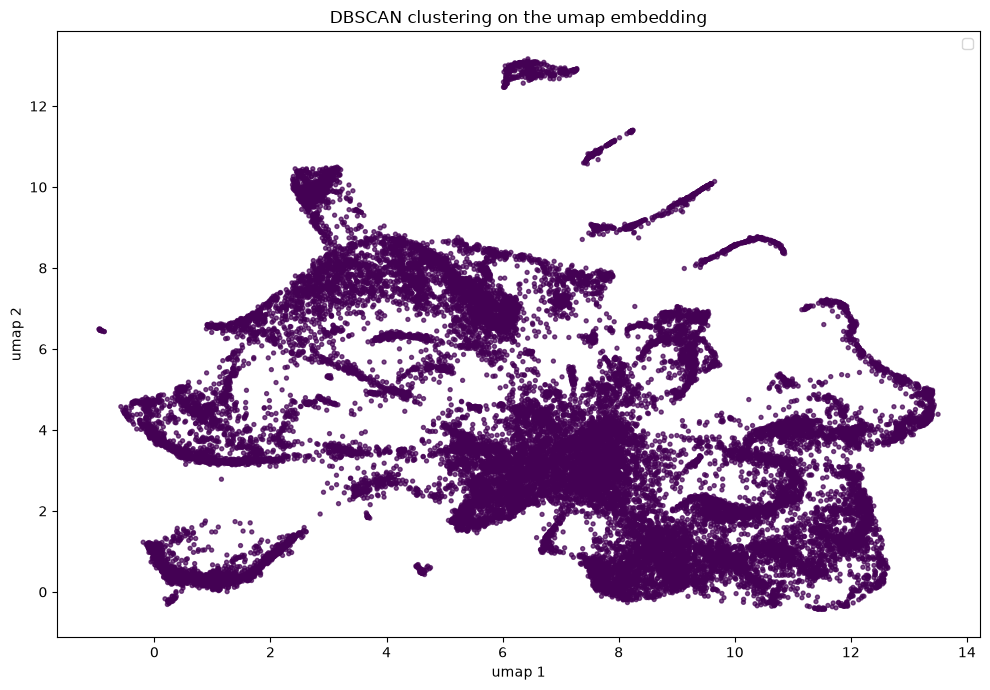

/home/rauls/Desktop/VirgoBRET/.venv/lib/python3.14/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


Estimated number of clusters: 6
Estimated number of noise points: 7556


/tmp/ipykernel_7155/27533357.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


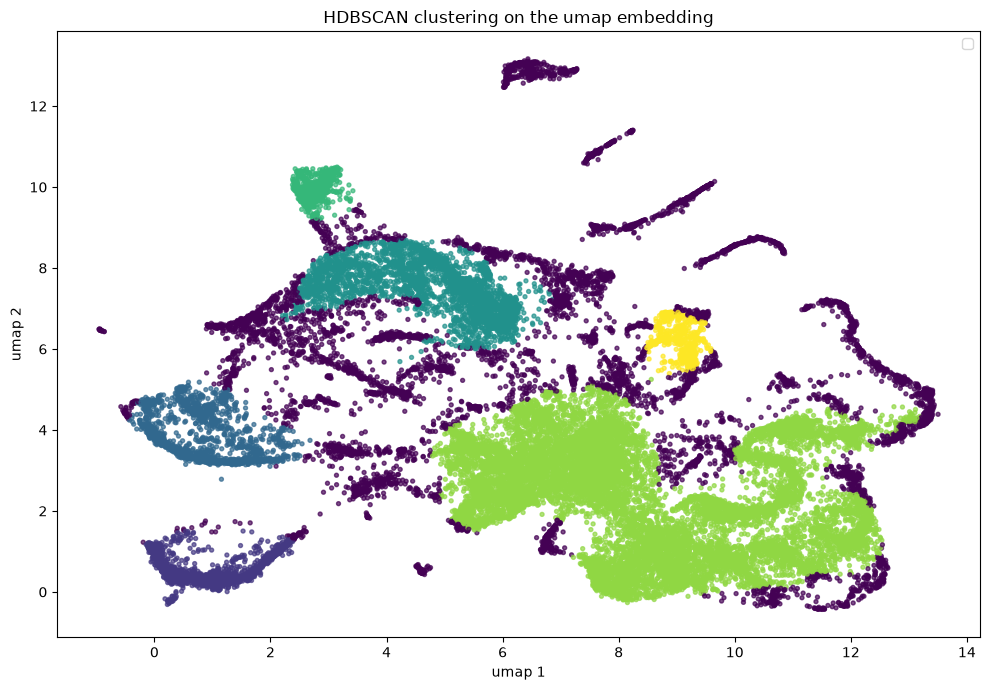

In [25]:
dbscan = DBSCAN(eps=4, min_samples=500, metric=METRIC).fit(A)

plt.figure(figsize=(10, 7))
plt.scatter(A[:, 0],A[:, 1],c=dbscan.labels_,cmap="viridis",s=8,alpha=0.7)

labels = dbscan.labels_
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

plt.title("DBSCAN clustering on the umap embedding")
plt.xlabel("umap 1")
plt.ylabel("umap 2")
plt.legend()
plt.tight_layout()
plt.show()

hdbscan = HDBSCAN(min_samples=500, metric=METRIC).fit(A)

plt.figure(figsize=(10, 7))
plt.scatter(A[:, 0],A[:, 1],c=hdbscan.labels_,cmap="viridis",s=8,alpha=0.7)

labels = hdbscan.labels_
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

plt.title("HDBSCAN clustering on the umap embedding")
plt.xlabel("umap 1")
plt.ylabel("umap 2")
plt.legend()
plt.tight_layout()
plt.show()